# TP4 :  Low-budget  Learning

# Introduction

**Context :**

Assume we are in a context where few "gold" labeled data are available for training, say

$$\mathcal{X}_{\text{train}} = \{(x_n,y_n)\}_{n\leq N_{\text{train}}}$$

where $N_{\text{train}}$ is small. Hence we are not in the context of classical well-organized benchmark datasets.

To make your life easier, you also get a validation set $\mathcal{X}_{\text{val}}$ representative of the test set, but you cannot use it for training. You can only use it to select the best model and hyperparameters.

A large test set $\mathcal{X}_{\text{test}}$ exists but is not accessible. We also assume that we have a limited computational budget (e.g., limited GPU access).


In this practical, we will use the `resnet10` architecture.

# QUESTIONS

## Grading

You will need to provide 4 files :
1. This Notebook
2. `utils.py`
3. `drawing_lora.png`
4. `cutmix.png`

Some of the code will be automatically graded so please follow the instructions carefully.

You will also need to participate in a competition on https://www.codabench.org to get your model evaluated on the hidden test set (the link to the competition will be provided on the course forum). Before submitting anything make sure to read the instructions on the competition page. The evaluation metric is the accuracy. However, *this is not a competition* as it is not necessary to get the best score to get a good grade. If you get a good score, and follow the instructions, you will get a good grade.

`utils.py` will be imported during the testing phase so please make sure:
- it does not execute any code when imported
- it does not depend on any module that is not standard (e.g., not `torch`, `torchvision`, `numpy`, etc.)


General instructions:
- Please provide clear and short answers between `<div class="alert alert-info">  <your answer>  </div>` tags (when it's not code).
- For each question that involves training a model:
    - Give the number of trained parameters.
    - You must provide the training curves (train & validation accuracy/loss vs epochs) in the notebook.
    - You must explain the choices you made (hyperparameters, etc). (A short justification is enough. For instance, "I used default hyperparameters." does not need further explanation. Or "I tried (0.1,0.01,0.001) and picked 0.01 because it gave the best validation accuracy." is enough.)
    - You must comment on the accuracy obtained.
- If you use a seed for reproducibility, please make sure it is a personal one using something like `hash("your_firstname_your_lastname")`.

<div class="alert alert-info">  Example of answer  </div>

In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 24.9 MB/s eta 0:00:00


In [51]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
from torchmetrics.classification import ConfusionMatrix
import seaborn as sns
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [52]:
import os

if not os.path.exists("data"):
    os.mkdir("data")
if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")
if not os.path.exists("data/TP4_images/north_dataset_test"):
    !cd data/TP4_images && wget -O north_dataset_train.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    !cd data/TP4_images && wget -O north_dataset_test.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip
dir_path = "data/TP4_images/"

In [53]:
val_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)

train_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_sample",
    transform=transforms.Compose([transforms.ToTensor()]),
)


metric = ConfusionMatrix(task="multiclass", num_classes=2).to(device)


def model_instancier(**kwargs):
    """
    Instanciate a ResNet10 model (ResNet18 with only 1 block per layer).

    Parameters
    ----------
    **kwargs: dict
        Keyword arguments to pass to the ResNet18 constructor.

    Returns
    -------
    model: nn.Module
        The instantiated ResNet10 model.
    """
    _model = models.resnet18(**kwargs)
    for i in range(1, 5):
        setattr(_model, f"layer{i}", getattr(_model, f"layer{i}")[0])
    return _model


base_model = model_instancier()
classifier_name = "fc"


print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 42
Validation dataset size: 42


### Helper function

In [54]:
def conf_mat(model, val_loader, device, metric):
    model.eval()

    metric.reset()

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            preds = torch.argmax(logits, dim=1)
            metric.update(preds, labels)
    conf_mat = metric.compute()
    return conf_mat

def plot_styled_confusion_matrix(conf_mat_tensor, class_names=["Classe 0", "Classe 1"]):
    """
    Affiche une matrice de confusion stylisée à partir d'un tenseur.
    """
    cm_array = conf_mat_tensor.cpu().numpy()

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(6, 5))

    ax = sns.heatmap(
        cm_array,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=1,
        linecolor='white',
        cbar=False
    )

    plt.title("Matrice de Confusion de l'Époque", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Vraies Étiquettes", fontsize=12, fontweight='medium')
    plt.xlabel("Prédictions du Modèle", fontsize=12, fontweight='medium')

    plt.tight_layout()
    plt.show()

In [55]:
def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in dataloader:
          data, target = data.to(device), target.to(device)
          output = model(data)
          correct += (output.argmax(dim=1) == target).sum().item()
          total += target.size(0)
    return correct / total

## Question 1:
>  Create `last_layer.py` to change the last layer of the resnet model so that it fits the problem.

In [56]:
import torch.nn as nn

class LastLayer(nn.Module):
    def __init__(self, in_features=512, out_features=2):
        super(LastLayer, self).__init__()
        self.out_features = out_features
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):
        return self.linear(x)

In [57]:
from last_layer import LastLayer

setattr(base_model, classifier_name, LastLayer())
assert (
    getattr(base_model, classifier_name).out_features == 2
)  # we could also change the last layer to have 1 output. Do it with 2 so that it matches our tests procedure during grading.

## Question 2:
> Provide a function `precompute_features` in `utils.py` that creates a new dataset from the features precomputed by the model.

In [58]:
def precompute_features(
    model: models.ResNet, dataset: torch.utils.data.Dataset, device: torch.device
) -> torch.utils.data.Dataset:
    """
    Create a new dataset with the features precomputed by the model.

    If the model is $f \circ g$ where $f$ is the last layer and $g$ is
    the rest of the model, it is not necessary to recompute $g(x)$ at
    each epoch as $g$ is fixed. Hence you can precompute $g(x)$ and
    create a new dataset
    $\mathcal{X}_{\text{train}}' = \{(g(x_n),y_n)\}_{n\leq N_{\text{train}}}$

    Arguments:
    ----------
    model: models.ResNet
        The model used to precompute the features
    dataset: torch.utils.data.Dataset
        The dataset to precompute the features from
    device: torch.device
        The device to use for the computation

    Returns:
    --------
    torch.utils.data.Dataset
        The new dataset with the features precomputed
    """
    original_fc = model.fc
    model.fc = nn.Identity()

    model = model.to(device)
    model.eval()

    batch_size = 128
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    prec_features = []
    prec_labels = []

    with torch.no_grad():
        for data, target in dataloader:
            data = data.to(device)

            features = model(data)

            prec_features.append(features.cpu())

            prec_labels.append(target.cpu())

    model.fc = original_fc

    final_features = torch.cat(prec_features, dim=0)
    final_labels = torch.cat(prec_labels, dim=0)

    return torch.utils.data.TensorDataset(final_features, final_labels)

<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:7: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-2312705791.py:7: SyntaxWarning: invalid escape sequence '\c'
  If the model is $f \circ g$ where $f$ is the last layer and $g$ is


## Question 3:
> Train the last layer of a randomly initialized resnet model.  Provide the training process in the notebook with training curve. Comment on the accuracy.

<div class="alert alert-info">
We train here only the last layer of a randomly initialized ResNet (1026 parameters $= 2 \times 512 + 2$).<br> <br> For all the practical we trained the models for 500 epochs, at a learning rate of 0.001 (yielding the best performance when trying with $l_r \in (0.1, 0.01, 0.001)$).
</div>

In [59]:
from utils import precompute_features

In [60]:
base_model = model_instancier()
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

In [61]:
print(f"Number of trainable parameters: {sum(p.numel() for p in base_model.fc.parameters() if p.requires_grad)}")

Number of trainable parameters: 1026


In [62]:
base_model.train()
for p in base_model.parameters():
    p.requires_grad = False

for p in base_model.fc.parameters():
    p.requires_grad = True

In [63]:
num_epochs = 500
lr = 0.001
batch_size = 32
optimizer = torch.optim.Adam(base_model.fc.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
train_loader = torch.utils.data.DataLoader(train_features_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_features_dataset, batch_size=batch_size, shuffle=False)

In [64]:
losses_train = []
losses_val = []
for epoch in range(num_epochs):
    base_model.train()
    epoch_loss_train = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = base_model.fc(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        epoch_loss_train += loss.item()
    epoch_loss_val = 0
    base_model.eval()
    with torch.no_grad():
      for data, target in train_loader:
          data, target = data.to(device), target.to(device)
          output = base_model.fc(data)
          loss = criterion(output, target)
          epoch_loss_val += loss.item()
    losses_train.append(epoch_loss_train)
    losses_val.append(epoch_loss_val)
    if epoch % 10 == 0:
      print(f"Epoch {epoch+1}/{num_epochs}, Loss train: {epoch_loss_train:.4f}, Loss val: {epoch_loss_val:.4f}")

Epoch 1/500, Loss train: 1.3742, Loss val: 1.3320
Epoch 11/500, Loss train: 1.1941, Loss val: 1.2772
Epoch 21/500, Loss train: 1.1984, Loss val: 1.1280
Epoch 31/500, Loss train: 1.0593, Loss val: 1.2062
Epoch 41/500, Loss train: 1.1928, Loss val: 1.2515
Epoch 51/500, Loss train: 1.1945, Loss val: 1.1979
Epoch 61/500, Loss train: 1.2309, Loss val: 1.1401
Epoch 71/500, Loss train: 1.1162, Loss val: 1.1926
Epoch 81/500, Loss train: 1.3212, Loss val: 1.1795
Epoch 91/500, Loss train: 1.0872, Loss val: 1.1665
Epoch 101/500, Loss train: 1.0984, Loss val: 1.1455
Epoch 111/500, Loss train: 1.3052, Loss val: 1.1747
Epoch 121/500, Loss train: 1.2278, Loss val: 1.1695
Epoch 131/500, Loss train: 1.1569, Loss val: 1.1400
Epoch 141/500, Loss train: 1.2707, Loss val: 1.0934
Epoch 151/500, Loss train: 1.0339, Loss val: 1.2821
Epoch 161/500, Loss train: 1.0976, Loss val: 1.1529
Epoch 171/500, Loss train: 1.0802, Loss val: 1.1551
Epoch 181/500, Loss train: 1.0796, Loss val: 1.1799
Epoch 191/500, Loss tra

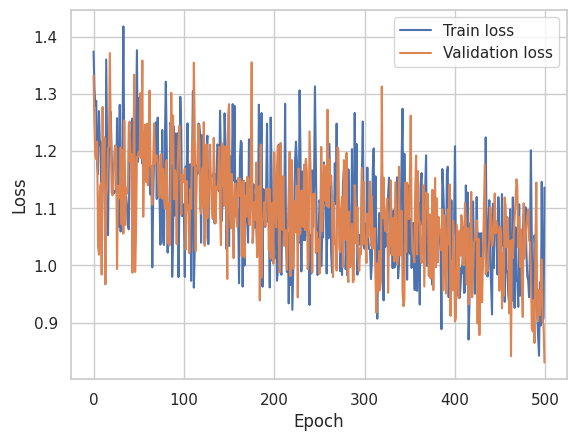

In [65]:
import matplotlib.pyplot as plt

plt.plot(losses_train, label="Train loss")
plt.plot(losses_val, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [66]:
acc_train = evaluate(base_model.fc, train_loader, device)
acc_val = evaluate(base_model.fc, val_loader, device)
print(f"Train accuracy: {acc_train:.4f}")
print(f"Validation accuracy: {acc_val:.4f}")

Train accuracy: 0.7619
Validation accuracy: 0.5000


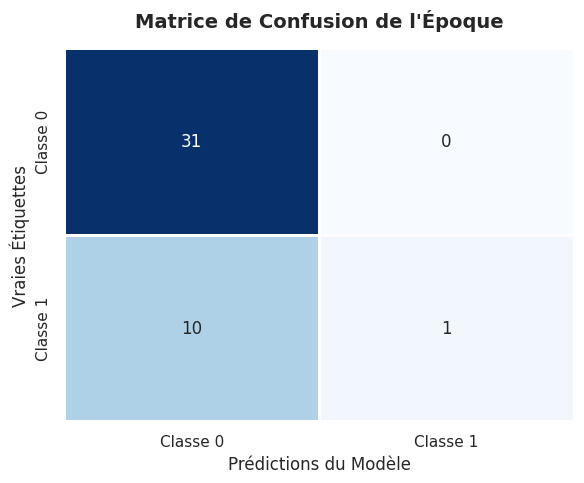

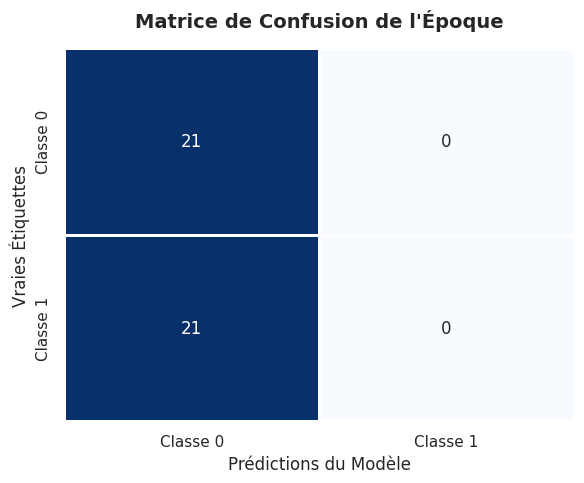

In [67]:
matrice_train = conf_mat(base_model.fc, train_loader, device, metric)
plot_styled_confusion_matrix(matrice_train)

matrice_val = conf_mat(base_model.fc, val_loader, device, metric)
plot_styled_confusion_matrix(matrice_val)

## Question 4:
>  Now start from a pretrained model on imagenet (https://pytorch.org/vision/stable/models.html#) and only train the last layer. Provide the training process in the notebook with training curve.

This is the first question evaluated on the codabench platform.

In [68]:
base_model = model_instancier(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

In [69]:
train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

<div class="alert alert-info">  You should achieve >80% accuracy on the val set.  </div>

In [70]:
base_model.train()
for p in base_model.parameters():
    p.requires_grad = False

for p in base_model.fc.parameters():
    p.requires_grad = True

In [71]:
lr = 0.001
optimizer = torch.optim.Adam(base_model.fc.parameters(), lr=lr)
train_loader = torch.utils.data.DataLoader(train_features_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_features_dataset, batch_size=batch_size, shuffle=False)

In [72]:
losses_train = []
losses_val = []
for epoch in range(num_epochs):
    base_model.train()
    epoch_loss_train = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = base_model.fc(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        epoch_loss_train += loss.item()
    epoch_loss_val = 0
    base_model.eval()
    with torch.no_grad():
      for data, target in train_loader:
          data, target = data.to(device), target.to(device)
          output = base_model.fc(data)
          loss = criterion(output, target)
          epoch_loss_val += loss.item()
    losses_train.append(epoch_loss_train)
    losses_val.append(epoch_loss_val)
    if epoch % 10 == 0:
      print(f"Epoch {epoch+1}/{num_epochs}, Loss train: {epoch_loss_train:.4f}, Loss val: {epoch_loss_val:.4f}")

Epoch 1/500, Loss train: 1.4809, Loss val: 1.3742
Epoch 11/500, Loss train: 1.1429, Loss val: 1.1309
Epoch 21/500, Loss train: 1.1523, Loss val: 1.0705
Epoch 31/500, Loss train: 0.9829, Loss val: 1.0948
Epoch 41/500, Loss train: 1.0736, Loss val: 1.1889
Epoch 51/500, Loss train: 0.8590, Loss val: 0.9940
Epoch 61/500, Loss train: 0.8521, Loss val: 0.9120
Epoch 71/500, Loss train: 0.8269, Loss val: 0.9679
Epoch 81/500, Loss train: 0.8689, Loss val: 0.8316
Epoch 91/500, Loss train: 0.9167, Loss val: 0.8143
Epoch 101/500, Loss train: 0.9069, Loss val: 0.6674
Epoch 111/500, Loss train: 0.7507, Loss val: 0.6494
Epoch 121/500, Loss train: 0.7859, Loss val: 0.8102
Epoch 131/500, Loss train: 0.5707, Loss val: 0.6857
Epoch 141/500, Loss train: 0.6566, Loss val: 0.6701
Epoch 151/500, Loss train: 0.6048, Loss val: 0.7782
Epoch 161/500, Loss train: 0.6865, Loss val: 0.6709
Epoch 171/500, Loss train: 0.6875, Loss val: 0.7189
Epoch 181/500, Loss train: 0.6646, Loss val: 0.6249
Epoch 191/500, Loss tra

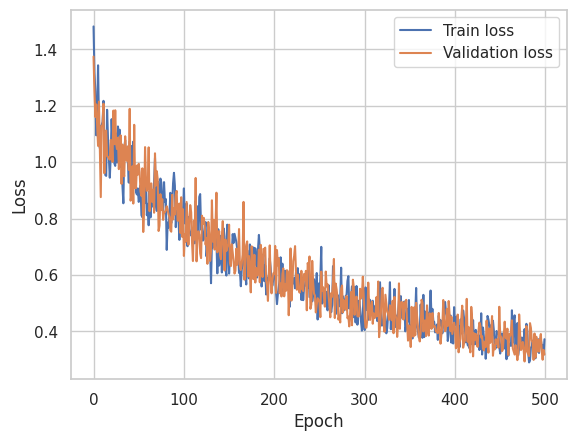

In [73]:
import matplotlib.pyplot as plt

plt.plot(losses_train, label="Train loss")
plt.plot(losses_val, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [74]:
acc_train = evaluate(base_model.fc, train_loader, device)
acc_val = evaluate(base_model.fc, val_loader, device)
print(f"Train accuracy: {acc_train:.4f}")
print(f"Validation accuracy: {acc_val:.4f}")

Train accuracy: 0.9524
Validation accuracy: 0.8333


### Save your model

In [75]:
# Save the last layer weights for grading on codabench
torch.save(getattr(base_model, classifier_name).state_dict(), "last_layer_finetune.pth")

### Check that you can load your model

In [76]:
model = model_instancier(weights="DEFAULT")
fc = LastLayer()
fc.load_state_dict(
    torch.load("last_layer_finetune.pth", weights_only=True, map_location=device)
)
setattr(model, classifier_name, fc)
model.eval()
pass

<div class="alert alert-info">
<strong> Conclusion: </strong> Comparing training strategies for the ResNet classification head demonstrates that transfer learning is inherently superior to training from scratch. Initializing the network with pre-trained weights is much more efficient than utilizing random weights, as the model starts with a sophisticated understanding of visual features. This approach avoids the prosaic performance limitations often associated with random initialization, which typically results in slower convergence and inferior final accuracy.
</div>

## Question 5:
> Perform  LoRA https://arxiv.org/pdf/2106.09685  on the model  ( We are perfectly fine if you use external library for this question only )

Intermediate question : Describe LoRA and the difference with LoRA for Convolutions in this paper : https://arxiv.org/pdf/2401.17868  in a few lines  (you do not have to implement ConvLora)

<div class="alert alert-info">
LoRA is a parameter-efficient fine-tuning (peft) technique that reduces training costs by adapting a pre-trained weight matrix $W_0$ through a trainable low-rank decomposition. Formally, for an input $x$, the standard LoRA forward pass is defined as $y = W_0 x + B A x$, where $A \in \mathbb{R}^{r \times k}$ is a down-projection matrix, $B \in \mathbb{R}^{d \times r}$ is an up-projection matrix, and $r$ represents a small rank bottleneck. <br> <br> Because standard LoRA relies purely on these linear projections, it lacks the spatial inductive biases necessary for specialized vision tasks. To address this limitation, Conv-LoRA integrates lightweight convolutional layers directly into the LoRA bottleneck structure between the $A$ and $B$ projections. The primary difference is that Conv-LoRA utilizes a Mixture-of-Experts approach, applying multiple parallel convolutional experts to the intermediate features ($z = Ax$) to dynamically inject multi-scale, image-related local priors before the final up-projection. Unlike standard linear LoRA, this convolution-augmented approach enables the architecture to recover high-level semantic information efficiently for complex image segmentation domains.
</div>

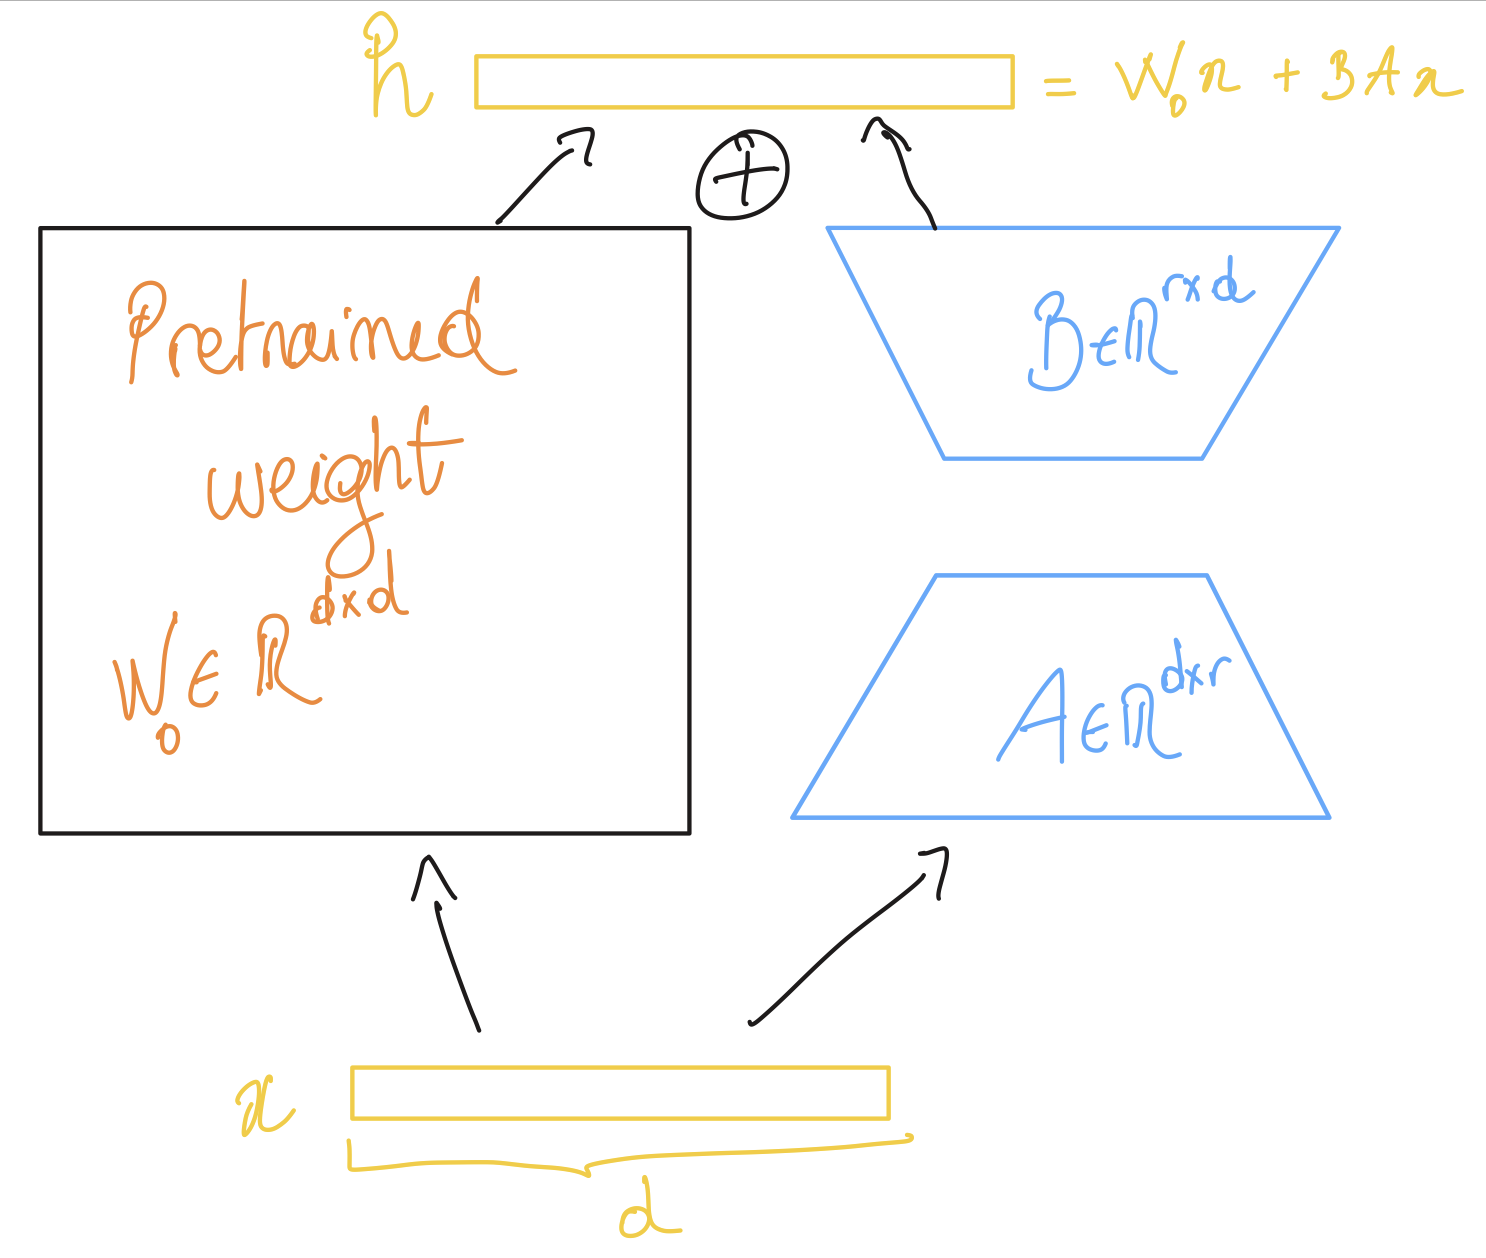

In [77]:
from peft import LoraConfig, get_peft_model, TaskType

model = model_instancier(weights="DEFAULT")
fc = LastLayer()
setattr(model, classifier_name, fc)
model = model.to(device)

In [78]:
print([(n, type(m)) for n, m in model.named_modules()])

[('', <class 'torchvision.models.resnet.ResNet'>), ('conv1', <class 'torch.nn.modules.conv.Conv2d'>), ('bn1', <class 'torch.nn.modules.batchnorm.BatchNorm2d'>), ('relu', <class 'torch.nn.modules.activation.ReLU'>), ('maxpool', <class 'torch.nn.modules.pooling.MaxPool2d'>), ('layer1', <class 'torchvision.models.resnet.BasicBlock'>), ('layer1.conv1', <class 'torch.nn.modules.conv.Conv2d'>), ('layer1.bn1', <class 'torch.nn.modules.batchnorm.BatchNorm2d'>), ('layer1.relu', <class 'torch.nn.modules.activation.ReLU'>), ('layer1.conv2', <class 'torch.nn.modules.conv.Conv2d'>), ('layer1.bn2', <class 'torch.nn.modules.batchnorm.BatchNorm2d'>), ('layer2', <class 'torchvision.models.resnet.BasicBlock'>), ('layer2.conv1', <class 'torch.nn.modules.conv.Conv2d'>), ('layer2.bn1', <class 'torch.nn.modules.batchnorm.BatchNorm2d'>), ('layer2.relu', <class 'torch.nn.modules.activation.ReLU'>), ('layer2.conv2', <class 'torch.nn.modules.conv.Conv2d'>), ('layer2.bn2', <class 'torch.nn.modules.batchnorm.Batc

In [79]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,

    target_modules=["conv1", "conv2", "downsample.0"],

    modules_to_save=["fc"],

    lora_dropout=0.1,
    bias="none"
)

In [80]:
peft_model = get_peft_model(model, lora_config)
peft_model = peft_model.to(device)

peft_model.print_trainable_parameters() # Trainable parameters

trainable params: 134,810 || all params: 5,041,628 || trainable%: 2.6739


## Question 6:
> Let's do some Data Augmentation https://en.wikipedia.org/wiki/Data_augmentation . Load some alteration of the data from the `torchvision.transforms` module and incorporate them into your training pipeline.

Intermediate question : Check CutMix  (https://pytorch.org/vision/stable/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py) and explain it with a small drawing.

You can find many other data augmentation techniques here: https://docs.pytorch.org/vision/0.15/transforms.html

This is the second question evaluated on the codabench platform.

<div class="alert alert-info">
CutMix performs a spatial swap between two images in a batch. It generates a binary mask $M$ based on a random bounding box whose size is determined by a ratio $\lambda$ sampled from a Beta distribution. <br> <br> The process follows two main operations: <ul> <li> <strong>Image Level</strong>: It replaces the pixel region of image $A$ inside the bounding box with the corresponding region from image $B$: $\tilde{x} = M \odot x_A + (1 - M) \odot x_B$. <li> <strong> Label Level</strong> : It interpolates the labels linearly based on the relative area $\lambda$ of the original image remaining: $\tilde{y} = \lambda y_A + (1 - \lambda) y_B$.This forces the model to identify objects from partial views, preventing over-reliance on a single dominant feature. </ul>
</div>

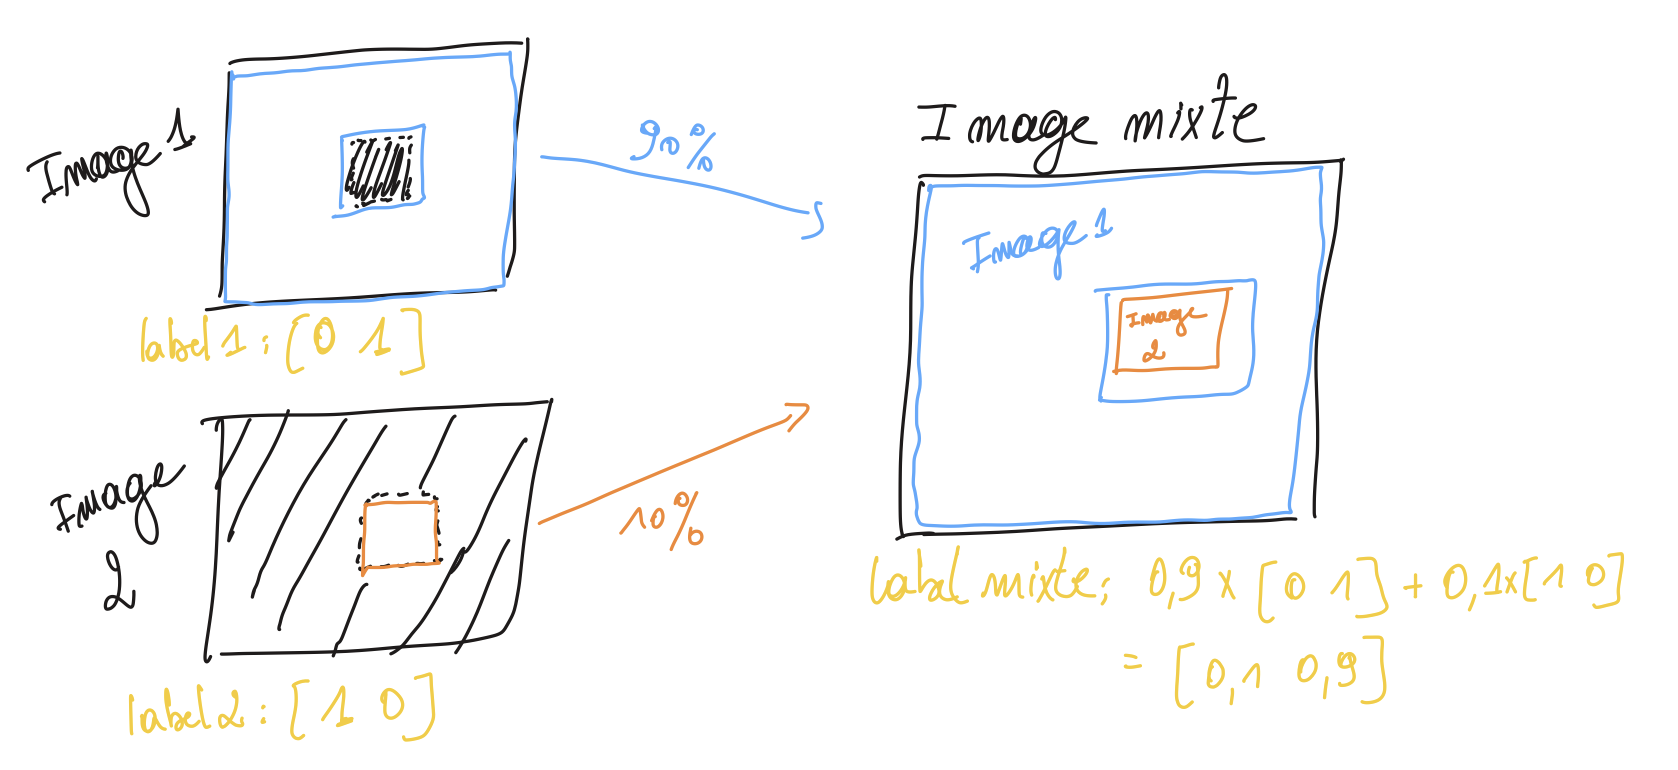

In [89]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=(224, 224), antialias=True),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize(size=(256, 256), antialias=True),
    transforms.CenterCrop(size=(224, 224)),
    transforms.ToTensor(),
])

train_dataset.transform = train_transforms
val_dataset.transform = val_transforms

In [ ]:
from torchvision.transforms import v2

cut_mix = v2.CutMix(num_classes=2)

In [ ]:
optimizer = torch.optim.Adam(peft_model.parameters(), lr=0.001)

In [ ]:
losses_train = []
losses_val = []
for epoch in range(num_epochs):
    peft_model.train()
    epoch_loss_train = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = peft_model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        epoch_loss_train += loss.item()
    epoch_loss_val = 0
    peft_model.eval()
    with torch.no_grad():
      for data, target in train_loader:
          data, target = data.to(device), target.to(device)
          output = peft_model(data)
          loss = criterion(output, target)
          epoch_loss_val += loss.item()
    losses_train.append(epoch_loss_train)
    losses_val.append(epoch_loss_val)
    if epoch % 10 == 0:
      print(f"Epoch {epoch+1}/{num_epochs}, Loss train: {epoch_loss_train:.4f}, Loss val: {epoch_loss_val:.4f}")

Epoch 1/500, Loss train: 1.3594, Loss val: 1.1859
Epoch 11/500, Loss train: 0.5630, Loss val: 0.8396
Epoch 21/500, Loss train: 0.3414, Loss val: 0.8948
Epoch 31/500, Loss train: 0.1833, Loss val: 0.5029
Epoch 41/500, Loss train: 0.2074, Loss val: 0.1353
Epoch 51/500, Loss train: 0.1040, Loss val: 0.1426
Epoch 61/500, Loss train: 0.1021, Loss val: 0.1465
Epoch 71/500, Loss train: 0.3497, Loss val: 0.1469
Epoch 81/500, Loss train: 0.1131, Loss val: 0.0433
Epoch 91/500, Loss train: 0.2195, Loss val: 0.0464
Epoch 101/500, Loss train: 0.0456, Loss val: 0.0948
Epoch 111/500, Loss train: 0.1078, Loss val: 0.0776
Epoch 121/500, Loss train: 0.0275, Loss val: 0.0820
Epoch 131/500, Loss train: 0.0478, Loss val: 0.0099
Epoch 141/500, Loss train: 0.0189, Loss val: 0.0505
Epoch 151/500, Loss train: 0.0296, Loss val: 0.0541
Epoch 161/500, Loss train: 0.0534, Loss val: 0.0239
Epoch 171/500, Loss train: 0.0112, Loss val: 0.0857
Epoch 181/500, Loss train: 0.0174, Loss val: 0.2469
Epoch 191/500, Loss tra

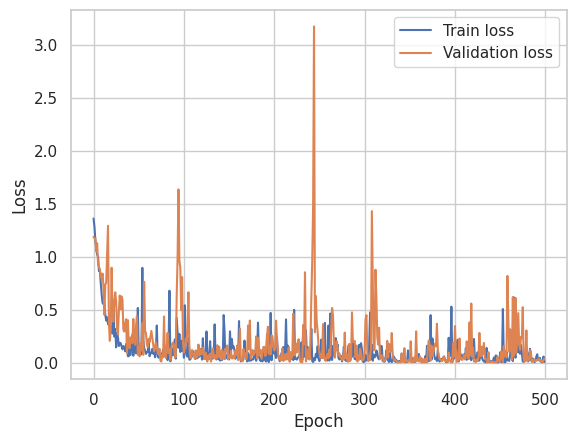

In [99]:
import matplotlib.pyplot as plt

plt.plot(losses_train, label="Train loss")
plt.plot(losses_val, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
acc_train = evaluate(peft_model, train_loader, device)
acc_val = evaluate(peft_model, val_loader, device)
print(f"Train accuracy: {acc_train:.4f}")
print(f"Validation accuracy: {acc_val:.4f}")

Train accuracy: 1.0000
Validation accuracy: 0.8810


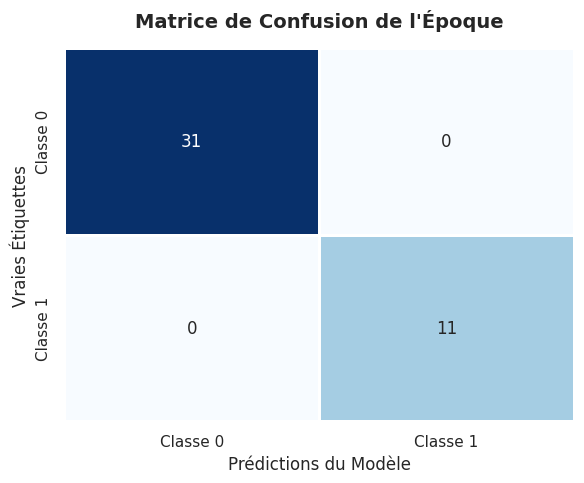

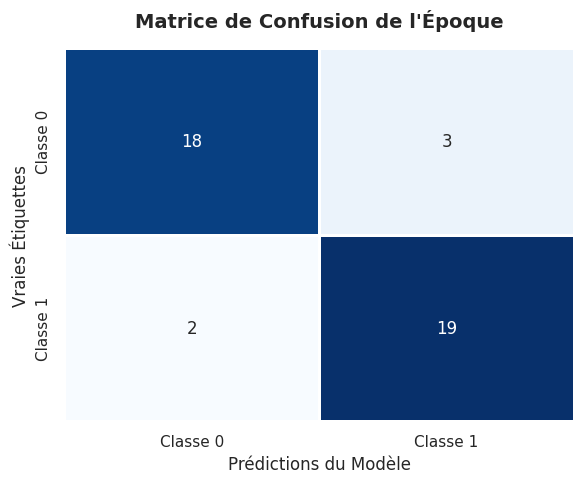

In [101]:
matrice_train = conf_mat(peft_model, train_loader, device, metric)
plot_styled_confusion_matrix(matrice_train)

matrice_val = conf_mat(peft_model, val_loader, device, metric)
plot_styled_confusion_matrix(matrice_val)

### Save your model

In [ ]:
# Merge LoRA weights back into the base model
peft_model.eval()
merged_model = peft_model.merge_and_unload()  # TODO: Merge LoRA weights back into the base model
assert isinstance(merged_model, models.ResNet)

torch.save(merged_model.state_dict(), "final_model.pth")

### Check that you can load your model

In [103]:
from last_layer import LastLayer

classifier_name = "fc"
device = torch.device("cpu")
model = model_instancier()
setattr(model, classifier_name, LastLayer())

model.load_state_dict(
    torch.load("final_model.pth", weights_only=True, map_location=device)
)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer2): BasicBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel

<div class="alert alert-info">  With LoRA and Data Augmentation you should be able to improve your model's performance compared to only fine-tuning the last layer. </div>

<div class="alert alert-info">
<strong> Conclusion: </strong> Results improve significantly when transitioning from head-only tuning to full-model adaptation using LoRA. This performance is further amplified by implementing advanced data augmentations including CutMix. By forcing the model to recognize objects from partial spatial information, the network learns to recover more robust semantic features. This combination of low-rank adaptation and diverse spatial augmentation consistently yields the highest classification and segmentation performance.

# Some advice

In our experiments, we only used SGD and a laptop GPU. We recommend not hesitating to use a large number of epochs (e.g., 100, 200, etc.). We did not use any learning rate scheduler but you can try if you want. Many data augmentation techniques exist, you can try them and see if they improve your performance. You can also try to combine them. For instance, you can try to combine CutMix with some geometric transformations (e.g., random crop, random horizontal flip, etc.).

The improvement from LoRA and data augmentation is quite hard to see on the small validation set. If you get even a small improvement on the validation set, it is likely that you will get a better score on the test set, except if you overfit the validation set. With an honest improvement on the validation set, you should be able to get a good grade.